<a href="https://colab.research.google.com/github/hindhammad24/Final-Assignment/blob/main/iat461_final_assiment_checkpoint1_hindhammad_301580180.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IAT 461 / 882  - Final Assignment
## Poké Pulls TCG : Pokémon Card Price Analysis

**Name:** `[Hind Hesham Hammad]`

**SFU ID:** `[301580180]`

**Date:** `[01/07/2026]`

**Client:** `[Ryan N]`  



## Project Overview

Poké Pulls TCG wants to better understand what factors influence Pokémon card market prices.
The goal of this project is to analyze card characteristics and identify patterns that may help estimate the value of individual cards.

Instead of manually judging every card based only on experience, this project explores whether information already available about each card can provide useful insights into its market value.

From a business perspective, understanding these patterns can help Poké Pulls make more informed decisions when evaluating cards and identifying potentially valuable cards.

From a data science perspective, this project begins with exploratory data analysis (EDA) to understand the dataset, identify important features, detect possible data issues, and determine whether the available information is suitable for future predictive modeling.

# Checkpoint 1 - Exploratory Data Analysis

The first stage of this project focuses on understanding the dataset before building any prediction models.

The main questions I want to investigate are:

- What information is available about each Pokémon card?
- How is card price distributed across the dataset?
- Are certain characteristics, such as rarity, set, or card type, related to higher prices?
- Are there missing values or data quality issues that need to be addressed?
- Which features may be useful for predicting card value in later stages?

### Initial Setup

The libraries above are used for different parts of the analysis:

- Pandas: used for loading, cleaning, and exploring the dataset.
- NumPy: used for numerical operations.
- Matplotlib and Seaborn: used to create visualizations that help identify patterns in the data.

Setting display options allows me to view the full dataset structure during exploration instead of hiding important information.

In [ ]:
# Import libraries needed for data exploration and visualization

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully")

Libraries imported successfully


### Dataset Overview



Before analyzing card prices, I first need to understand the structure and quality of the dataset.

This step helps identify what information is available about each Pokémon card, what variables may be useful for predicting market value, and whether any cleaning is required before further analysis.

From the client's perspective, this provides an understanding of what card information can be used when evaluating prices.

From a data science perspective, inspecting the dataset prevents incorrect assumptions and helps identify possible issues such as missing values, incorrect data types, or variables that may require transformation.

In [ ]:
# Load the Pokémon card price dataset

df = pd.read_csv("pokemon_card_prices.csv")

# Display first few rows
df.head()

,name,set,series,release_date,rarity,supertype,subtypes,types,hp,artist,market_price_usd
0,Scatterbug,Scarlet & Violet,Scarlet & Violet,2023/03/31,Common,Pokémon,Basic,Grass,30,sowsow,0.17
1,Pineco,Scarlet & Violet,Scarlet & Violet,2023/03/31,Common,Pokémon,Basic,Grass,60,Shigenori Negishi,0.12
2,Cacturne,Scarlet & Violet,Scarlet & Violet,2023/03/31,Uncommon,Pokémon,Stage 1,Grass,130,DOM,0.21
3,Gogoat,Scarlet & Violet,Scarlet & Violet,2023/03/31,Common,Pokémon,Stage 1,Grass,130,Gemi,0.14
4,Sprigatito,Scarlet & Violet,Scarlet & Violet,2023/03/31,Common,Pokémon,Basic,Grass,70,Saya Tsuruta,0.27


In [ ]:
# Check dataset size

df.shape

(1000, 11)

In [ ]:
# Display column names

df.columns

Index(['name', 'set', 'series', 'release_date', 'rarity', 'supertype',
       'subtypes', 'types', 'hp', 'artist', 'market_price_usd'],
      dtype='object')

In [ ]:
# Check data types and missing values

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              1000 non-null   object 
 1   set               1000 non-null   object 
 2   series            1000 non-null   object 
 3   release_date      1000 non-null   object 
 4   rarity            1000 non-null   object 
 5   supertype         1000 non-null   object 
 6   subtypes          1000 non-null   object 
 7   types             1000 non-null   object 
 8   hp                1000 non-null   int64  
 9   artist            1000 non-null   object 
 10  market_price_usd  1000 non-null   float64
dtypes: float64(1), int64(1), object(9)
memory usage: 86.1+ KB


In [ ]:
# Basic numerical summary

df.describe()

,hp,market_price_usd
count,1000.000000,1000.000000
mean,120.840000,5.390110
std,67.766413,31.211284
min,30.000000,0.020000
25%,70.000000,0.150000
50%,100.000000,0.270000
75%,140.000000,0.872500
max,340.000000,580.920000


#### Initial Dataset Findings

The dataset contains **1,000 Pokémon cards with 11 features**. Each row represents one individual Pokémon card, including information about its identity, release details, characteristics, and market value.

The available features include both categorical and numerical information. Categorical features include details such as card set, series, rarity, type, subtype, and artist. Numerical features include HP and the target variable, market price in USD.

The target variable for future prediction is **market_price_usd**, which represents the current market value of each card. Since this variable contains continuous numerical values, the future modeling stage will likely focus on a regression approach.

From the client's perspective, the dataset provides several possible factors that may influence card value, such as rarity, release information, and card characteristics.

From a data science perspective, the dataset appears suitable for further analysis because it contains a mixture of categorical and numerical variables. However, most variables are stored as categorical text values, meaning feature encoding will likely be required before building predictive models.

### Data Quality Check

#### Missing Values

Before exploring relationships between card features and price, I need to check whether the dataset contains missing information.

Missing values can affect analysis and future prediction models because some algorithms cannot directly process incomplete records. Understanding the quality of the dataset helps determine whether cleaning steps are necessary.

In [ ]:
# Check the number of missing values in each column

df.isnull().sum()

,0
name,0
set,0
series,0
release_date,0
rarity,0
supertype,0
subtypes,0
types,0
hp,0
artist,0


##### Missing Values Findings

The missing value check shows that **all 11 columns contain 1,000 non-null values**, meaning there are no missing entries in the dataset.

This means no rows need to be removed or filled with estimated values during the initial cleaning stage.

From the client's perspective, this is useful because all available card information can be considered during the analysis without losing observations.

From a data science perspective, the absence of missing values allows the exploration phase to continue without requiring imputation methods. However, further checks are still required to identify issues such as duplicate records, unusual values, or highly skewed variables.

#### Duplicate Records Check

Duplicate rows can create bias during analysis because the same card information would be counted multiple times.

Checking for duplicates ensures that each record represents a unique observation.

In [ ]:
# Check duplicate rows

df.duplicated().sum()

np.int64(0)

##### Duplicate Records Findings

The duplicate records check found **0 duplicated rows** in the dataset.

This indicates that each row represents a unique Pokémon card observation, preventing repeated cards from influencing the analysis.

For the client, this increases confidence that the price patterns discovered later are based on individual cards rather than repeated records.

From a data science perspective, no duplicate removal is required before continuing with exploratory data analysis.

#### Additional Data Quality Checks

Before moving into exploratory analysis, additional validation checks were performed to identify possible data quality issues beyond missing values and duplicate rows.

The dataset was checked for:
- Negative numerical values
- Impossible zero values
- Unrealistic numerical ranges
- Invalid dates
- Empty text values
- Inconsistent categories
- Features with no variation

These checks help confirm that the dataset is reliable and identify any values that may require further investigation during analysis.

##### Checking for Negative Values

Negative values would represent invalid data for some features.

For example:
- Pokémon HP cannot be negative.
- Market price cannot be negative.

This check identifies whether any numerical columns contain impossible negative values.

In [ ]:
# Check negative values in numerical columns

numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns

negative_values = (df[numeric_columns] < 0).sum()

negative_values

,0
hp,0
market_price_usd,0


###### Finding

No negative values were found in the numerical features.

This means all numerical measurements fall within valid ranges, so no correction is required.

##### checking for Zero Values

Some variables should not contain zero values because zero would represent an impossible observation.

For this dataset:
- HP = 0 would represent an invalid card.
- Market price = 0 would represent a card with no value.

This check helps identify potentially incorrect records.

In [ ]:
# Check zero values in important numerical columns

zero_values = (df[numeric_columns] == 0).sum()

zero_values

,0
hp,0
market_price_usd,0


###### Finding

No zero values were found in the checked numerical features.

All cards contain valid HP and market price information.

##### Checking Numerical Ranges

Summary statistics were examined to identify unusual values or possible outliers.

The minimum, median, average, and maximum values help determine whether numerical features have realistic ranges.

In [ ]:
# Display numerical summary statistics

df[numeric_columns].describe()

,hp,market_price_usd
count,1000.000000,1000.000000
mean,120.840000,5.390110
std,67.766413,31.211284
min,30.000000,0.020000
25%,70.000000,0.150000
50%,100.000000,0.270000
75%,140.000000,0.872500
max,340.000000,580.920000


###### Finding

The numerical ranges appear reasonable.

HP values fall within expected Pokémon card ranges.

The market price variable contains very large differences between the median and maximum value. This suggests the presence of expensive collectible cards.

These values are not removed because high-value cards are expected in collectible markets. Instead, the price distribution will be investigated during exploratory analysis.

##### Checking Date Validity

The release date column was checked to ensure that all values can be correctly interpreted as dates.

Invalid dates could affect time-based analysis.

In [ ]:
# Convert release date to datetime format

df['release_date'] = pd.to_datetime(
    df['release_date'],
    errors='coerce'
)

# Count invalid dates

invalid_dates = df['release_date'].isna().sum()

invalid_dates

np.int64(0)

###### Finding

No invalid dates were found.

All release dates were successfully converted into datetime format.

##### Checking Empty Text Values

Missing values do not always appear as NaN.

Some datasets contain empty strings ("") instead.

This check identifies blank text entries that could affect categorical analysis.

In [ ]:
# Check empty strings in object columns

text_columns = df.select_dtypes(include='object').columns

empty_strings = (
    df[text_columns]
    .apply(lambda x: (x == "").sum())
)

empty_strings

,0
name,0
set,0
series,0
rarity,0
supertype,0
subtypes,0
types,0
artist,0


##### Finding

No empty text values were found.

All categorical fields contain valid text entries.

##### Checking Category Consistency

Categorical features were examined to identify unexpected values or columns with no variation.

Features with only one unique value provide no useful information for modelling.

In [ ]:
# Count unique values in categorical columns

categorical_columns = df.select_dtypes(include='object').columns

unique_categories = df[categorical_columns].nunique()

unique_categories

,0
name,620
set,10
series,2
rarity,16
supertype,1
subtypes,13
types,10
artist,131


###### Finding

Most categorical features contain multiple meaningful categories.

However, the `supertype` column contains only one unique value:

"Pokémon"

Since this feature has no variation, it does not provide useful information for analysis or prediction and may be removed during feature selection.

#### Data Quality Check Summary

After performing additional validation checks:


1. Missing values = No missing values found
2. Duplicate rows = No duplicate rows found
3. Negative values = None detected
4. Zero values = None detected
5. Invalid dates = None detected
6. Empty text values = None detected
7. Unrealistic numerical ranges = None detected
8. Price outliers = Present and will be investigated
9. Constant features = supertype contains one unique value

Overall, the dataset appears clean and suitable for further exploratory analysis.

The only issue requiring further investigation is the skewed distribution of market prices caused by high-value collectible cards.

## Exploratory Data Analysis (EDA)

### Numerical EDA

After completing the data quality checks, exploratory data analysis was performed to understand the main patterns and relationships within the dataset.

The main focus is the market price variable because it represents the value we want to understand and potentially predict.

The analysis includes:
- Distribution of market prices
- Comparison between average and median values
- Relationship between Pokémon attributes and price
- Identification of possible outliers

#### Dataset Overview

Before visualizing the variables, basic statistics were reviewed to understand the scale and distribution of numerical features.

In [ ]:
df.describe()

,release_date,hp,market_price_usd
count,1000,1000.000000,1000.000000
mean,2021-11-27 06:17:16.799999744,120.840000,5.390110
min,2019-11-15 00:00:00,30.000000,0.020000
25%,2020-05-01 00:00:00,70.000000,0.150000
50%,2021-12-07 12:00:00,100.000000,0.270000
75%,2023-06-09 00:00:00,140.000000,0.872500
max,2023-08-11 00:00:00,340.000000,580.920000
std,NaN,67.766413,31.211284


##### Observation

The dataset contains 1,000 Pokémon cards.

The market price has a mean of **$5.39**, while the median price is only **$0.27**. This large difference shows that the distribution is strongly affected by a small number of expensive cards.

The minimum market price is **$0.02**, while the maximum price reaches **$580.92**, showing a very large range between typical cards and rare high-value cards.

The standard deviation of **$31.21** is also much larger than the median price, which indicates high variation in card values.

Because collectible cards often contain a small number of extremely valuable items, this suggests the market price distribution may be heavily right-skewed.

#### Market Price Distribution

A histogram was created to visualize how market prices are distributed.

This helps determine whether the target variable follows a normal distribution or requires transformation.

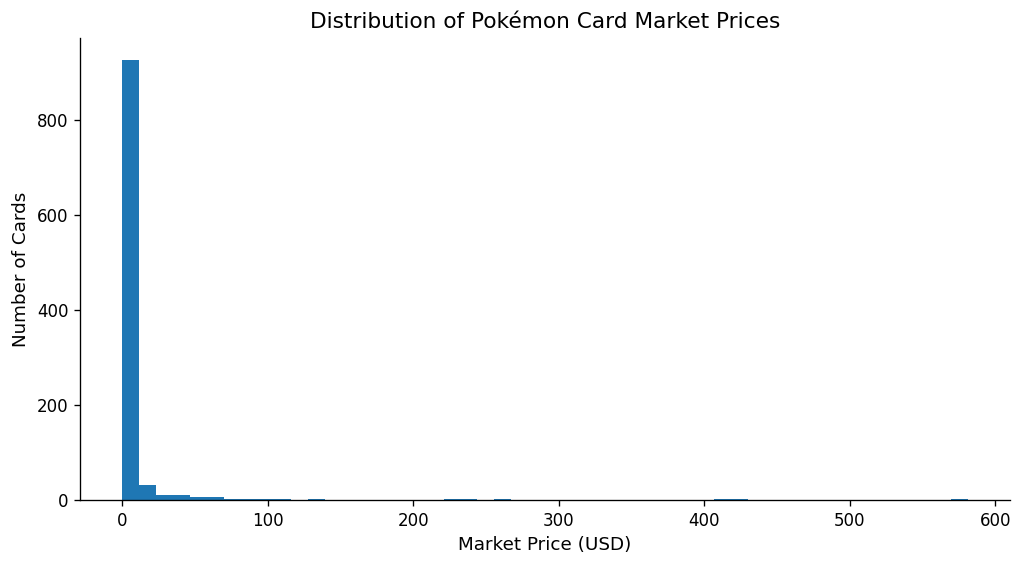

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(df['market_price_usd'], bins=50)
plt.xlabel("Market Price (USD)")
plt.ylabel("Number of Cards")
plt.title("Distribution of Pokémon Card Market Prices")

plt.show()


##### Observation

The market price distribution is highly right-skewed.

The histogram shows that the majority of Pokémon cards are concentrated at lower price values, while only a small number of cards reach much higher prices.

This matches the earlier summary statistics, where the median price was **$0.27** compared to the mean price of **$5.39** and the maximum price of **$580.92**.

From the client's perspective, this shows that most cards have relatively low market values, but a small number of rare and expensive cards can significantly affect the overall pricing landscape.

From a data science perspective, this indicates that market price contains extreme values that may influence future prediction models. Instead of removing these cards, they should be investigated further because they likely represent meaningful high-value collectibles rather than incorrect data.

#### Log Transformation of Market Price

Because market price contains extreme high-value cards, a log transformation was applied to reduce skewness and make patterns easier to observe.

The transformation does not remove expensive cards; it compresses their scale.

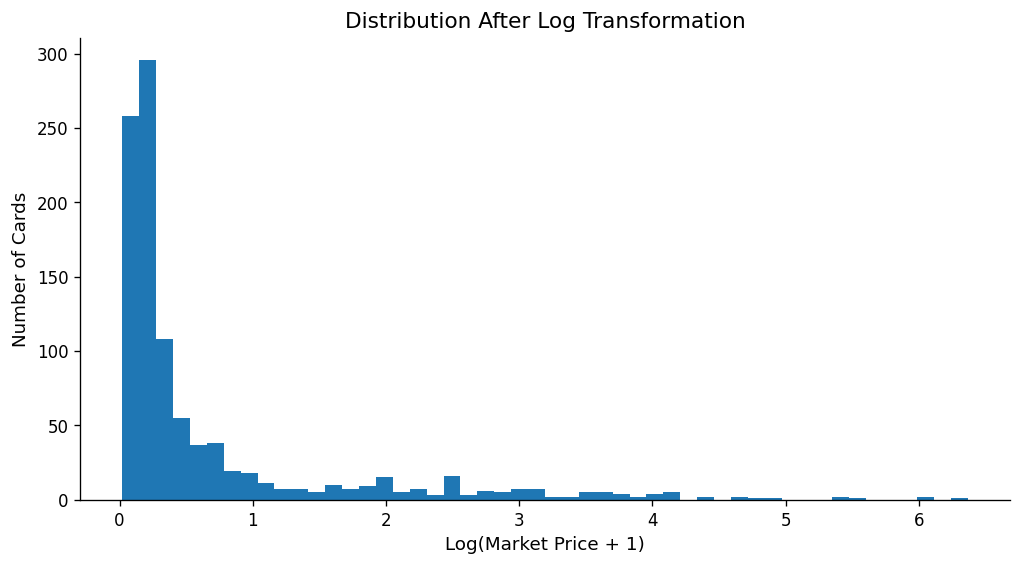

In [ ]:
import numpy as np
df['log_market_price'] = np.log1p(df['market_price_usd'])

plt.figure(figsize=(10,5))

plt.hist(df['log_market_price'], bins=50)

plt.xlabel("Log(Market Price + 1)")
plt.ylabel("Number of Cards")
plt.title("Distribution After Log Transformation")

plt.show()

##### Observation

After applying a log transformation to the market price, the distribution becomes easier to interpret because extremely expensive cards are compressed closer to the rest of the dataset.

The transformation does not remove high-value cards; instead, it reduces their influence on the visualization and future modelling process.

From the client's perspective, this shows that Pokémon card prices naturally contain large differences between common cards and rare collectibles.

From a data science perspective, the transformed price variable may be useful for future prediction models because it reduces the impact of extreme values while keeping important information about expensive cards.

#### Comparing Mean and Median Market Price

The mean and median were compared because a large difference between them indicates skewness caused by extreme values.

In [ ]:
mean_price = df['market_price_usd'].mean()
median_price = df['market_price_usd'].median()

print("Mean:", mean_price)
print("Median:", median_price)

Mean: 5.39011
Median: 0.27


##### Observation

The mean market price is $5.39, while the median market price is only $0.27.

This large difference indicates that the dataset is heavily influenced by a small number of high-value cards.

The median provides a better representation of a typical Pokémon card because most cards are closer to the lower price range, while a few expensive cards increase the overall average.

From the client's perspective, this highlights that most inventory consists of lower-priced cards, but rare high-value cards may require special attention when making pricing decisions.

From a data science perspective, this confirms that market price is not normally distributed and that outliers should be considered during feature engineering and model development.

#### Market Price by Rarity

Rarity is expected to influence card value because rare cards are usually more collectible.

The relationship between rarity categories and market price was explored.

<Figure size 1440x720 with 0 Axes>

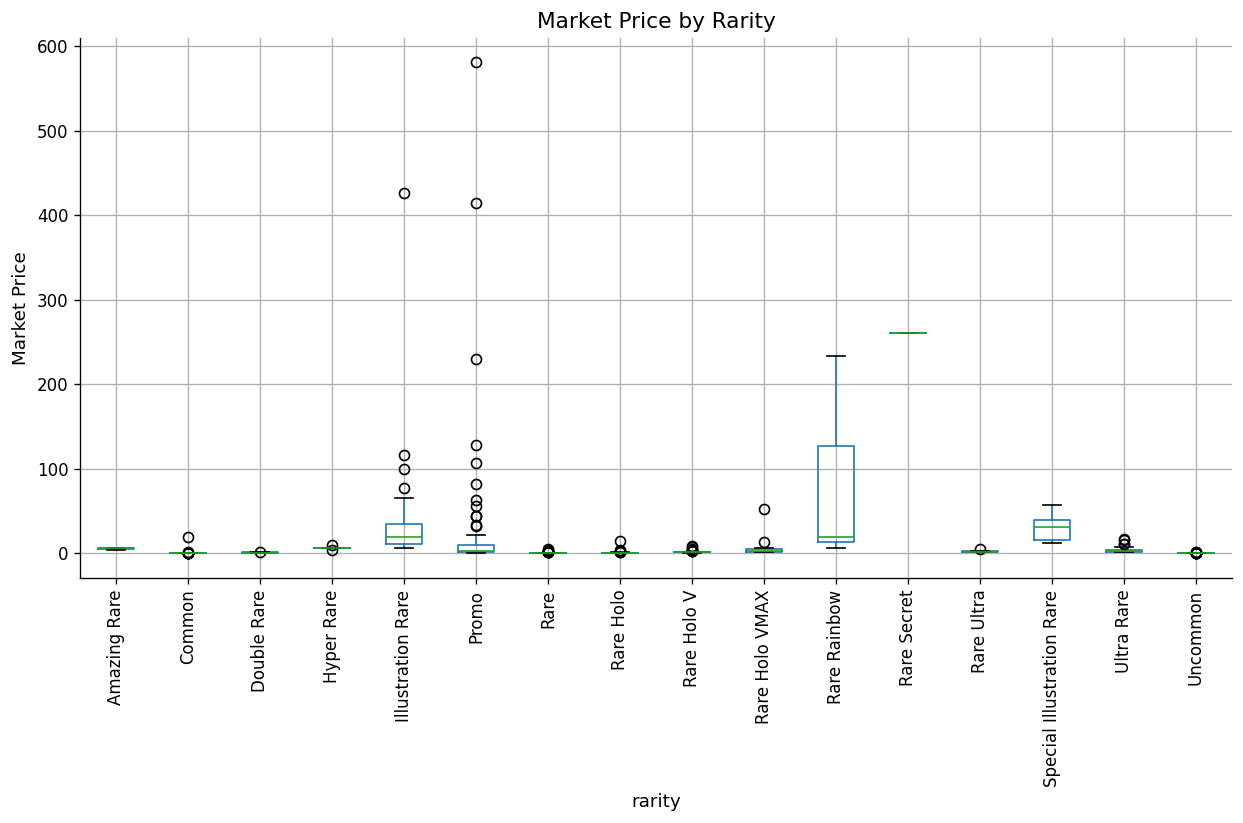

In [ ]:
plt.figure(figsize=(12,6))

df.boxplot(
    column='market_price_usd',
    by='rarity',
    rot=90,
    figsize=(12,6)
)

plt.title("Market Price by Rarity")
plt.suptitle("")

plt.ylabel("Market Price")

plt.show()

##### Observation

The boxplot shows that market prices vary significantly between different rarity categories.

Lower rarity categories, such as Common and Uncommon cards, generally have lower market prices, while some higher rarity categories show much larger price ranges.

Several rarity groups contain extreme outliers, especially Promo cards, where some cards reach very high market values compared to the typical cards in that category.

From the client's perspective, this suggests that rarity is an important factor when evaluating card value because certain rarity groups are more likely to contain expensive cards.

From a data science perspective, rarity appears to be an important feature for future prediction models. However, the presence of outliers within each category shows that rarity alone cannot completely explain price differences, meaning additional card features should also be investigated.

#### Numerical Feature Correlation

Correlation analysis was used to identify numerical variables that may have relationships with market price.

Correlation does not prove causation, but it helps identify useful features.

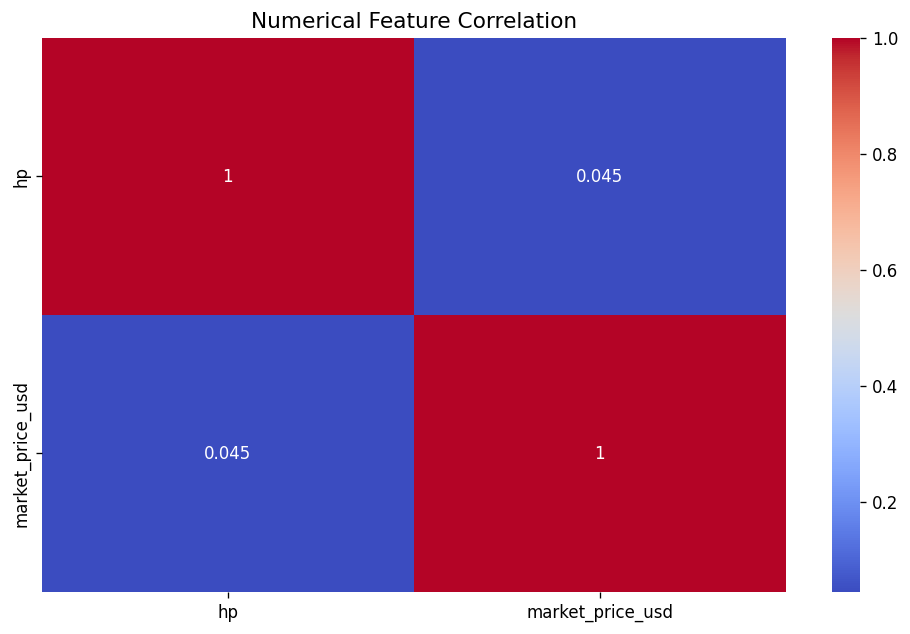

In [ ]:
import seaborn as sns

plt.figure(figsize=(10,6))

sns.heatmap(
    df[numeric_columns].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Numerical Feature Correlation")

plt.show()

##### Observation

The correlation analysis shows that HP has a very weak positive relationship with market price, with a correlation value of **0.045**.

This suggests that cards with higher HP do not necessarily have higher market values. While HP represents a gameplay characteristic of a Pokémon card, it does not appear to be an important factor when explaining price differences in this dataset.

From the client's perspective, this means that using HP alone would not be a reliable way to estimate card value.

From a data science perspective, HP may have limited predictive importance as a standalone numerical feature. However, it should not automatically be removed because other features, such as rarity, set, or card type, may interact with HP and provide additional information when combined in a model.

### Categorical EDA

#### Distribution of Card Rarity

Rarity is expected to influence market value because collectible cards are often priced based on scarcity.

Before analyzing its relationship with price, the distribution of rarity categories was examined to understand how many examples exist in each group.

This helps determine whether some rarity categories may have limited representation in the dataset.

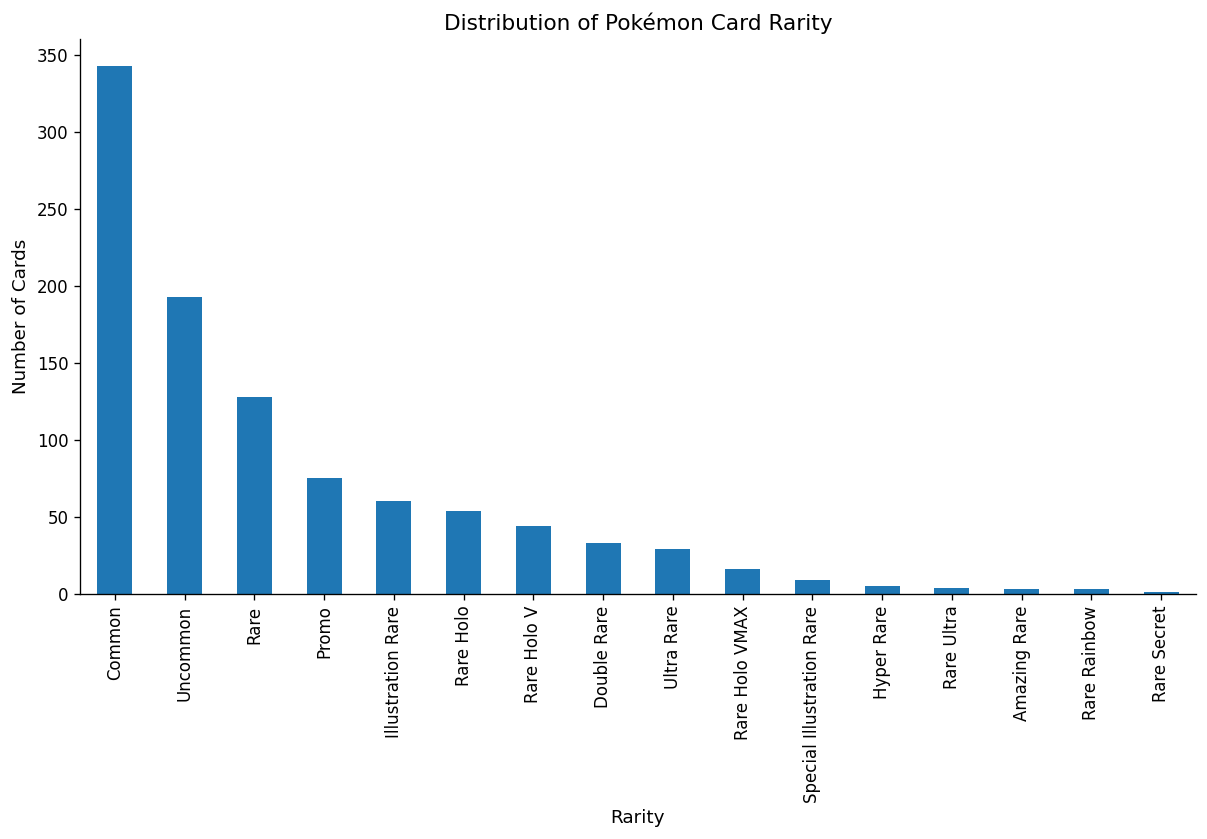

In [ ]:
plt.figure(figsize=(12,6))

df['rarity'].value_counts().plot(
    kind='bar'
)

plt.xlabel("Rarity")
plt.ylabel("Number of Cards")
plt.title("Distribution of Pokémon Card Rarity")

plt.xticks(rotation=90)

plt.show()

##### Observation

The rarity distribution is not evenly balanced across categories.

Common cards represent the largest portion of the dataset, followed by Uncommon and Rare cards. These categories contain many more examples compared to higher rarity categories.

Several premium rarity groups, such as Amazing Rare, Rare Rainbow, and Rare Secret, have very limited representation in the dataset.

From the client's perspective, this reflects the real collectible card market where common cards are widely available, while highly rare cards are much less frequent.

From a data science perspective, the imbalance between rarity categories should be considered during modelling. Categories with very few examples may have less reliable estimates because there is limited data available to learn their relationship with market price.

#### Market Price by Pokémon Set

The Pokémon set represents the expansion where a card was released.

Different sets may have different collector demand, availability, and historical importance, which can influence market price.

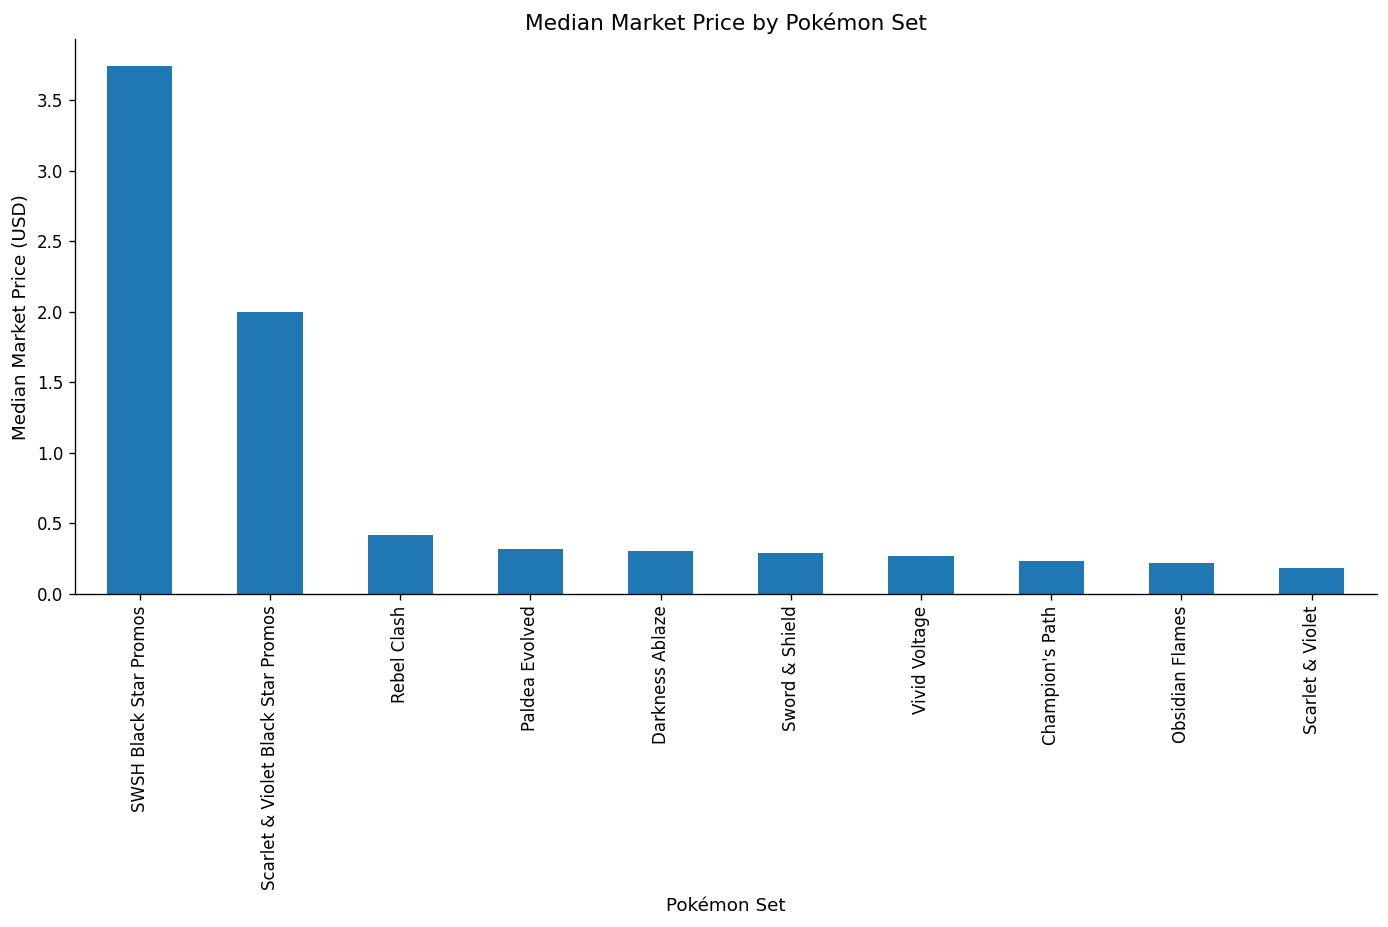

In [ ]:
plt.figure(figsize=(14,6))

df.groupby('set')['market_price_usd'].median().sort_values(ascending=False).plot(
    kind='bar'
)

plt.xlabel("Pokémon Set")
plt.ylabel("Median Market Price (USD)")
plt.title("Median Market Price by Pokémon Set")

plt.xticks(rotation=90)

plt.show()

##### Observation

The median market price varies significantly between Pokémon sets.

The highest median prices are found in promotional sets, especially **SWSH Black Star Promos** and **Scarlet & Violet Black Star Promos**, which have noticeably higher typical card values compared to the other sets in the dataset.

Most regular expansion sets have much lower median prices, suggesting that the set a card belongs to may influence its market value.

From the client's perspective, this indicates that the card's release set is an important factor to consider when evaluating inventory because some collections may contain generally higher-value cards.

From a data science perspective, the `set` feature appears to contain useful predictive information. However, the differences may also be affected by the types of cards included in each set, such as the number of rare or promotional cards, so additional features should be considered before drawing conclusions.

#### Market Price by Pokémon Type

The Pokémon type represents the category of the Pokémon featured on the card.

This analysis explores whether certain Pokémon types tend to have different market values. While type alone may not determine price, it can reveal patterns that may be useful for future modelling.

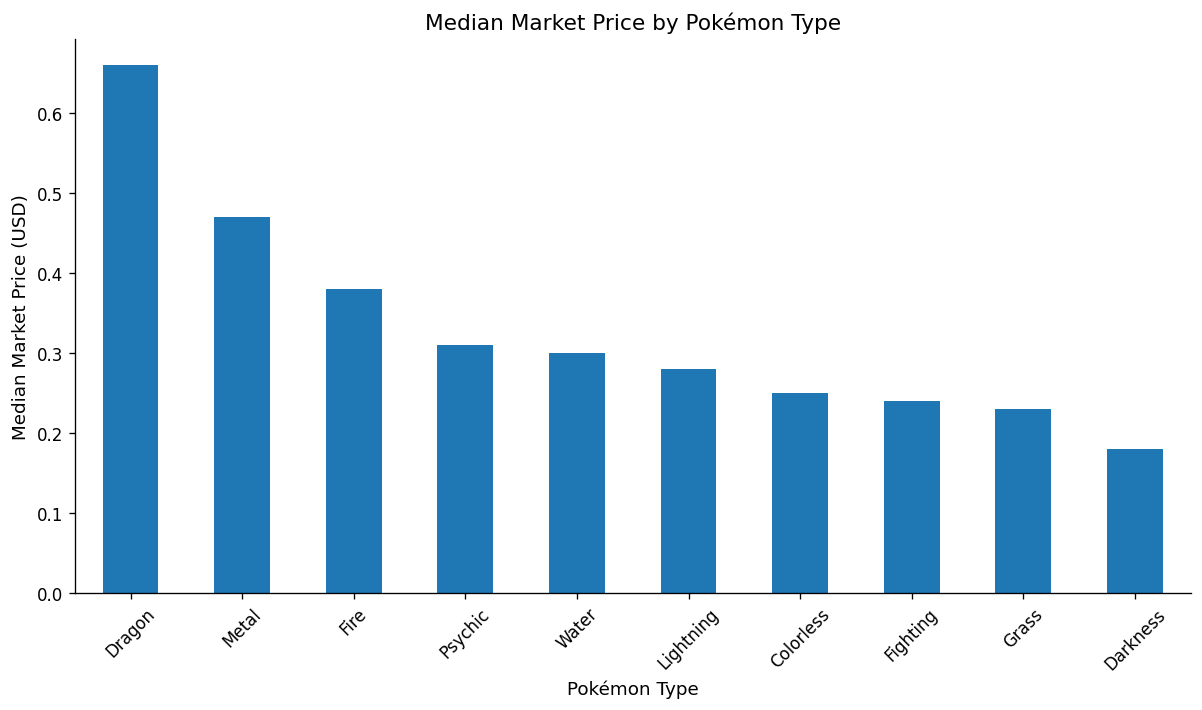

In [ ]:
plt.figure(figsize=(12,6))

df.groupby('types')['market_price_usd'].median().sort_values(ascending=False).plot(
    kind='bar'
)

plt.xlabel("Pokémon Type")
plt.ylabel("Median Market Price (USD)")
plt.title("Median Market Price by Pokémon Type")

plt.xticks(rotation=45)

plt.show()

##### Observation

The median market price varies between different Pokémon types, although the differences are smaller compared to factors such as rarity and set.

Dragon-type cards have the highest median market price in this dataset, followed by Metal and Fire types. Other types show relatively similar median values, with Darkness having the lowest median price among the categories shown.

From the client's perspective, this suggests that Pokémon type may provide some additional context when evaluating card value, but it is unlikely to be the main factor determining price.

From a data science perspective, type may contain some predictive information, but the weaker differences between categories suggest that it should be combined with stronger features such as rarity, set, and card characteristics rather than used as a standalone predictor.

### Temporal EDA

#### Market Price by Release Year

The release date may influence card value because older cards can have different levels of availability, collector interest, and market demand.

The release year was extracted from the release date to explore whether card prices vary across different release periods.

In [ ]:
# Convert release_date from string to datetime format

df['release_date'] = pd.to_datetime(df['release_date'])

# Check the new data type

df['release_date'].dtype

dtype('<M8[ns]')

##### Converting Release Date Format

The release date column was initially stored as text (object type), which prevents date-based analysis.

To analyze whether release timing affects market price, the column was converted into a datetime format. This allows extracting useful features such as release year.

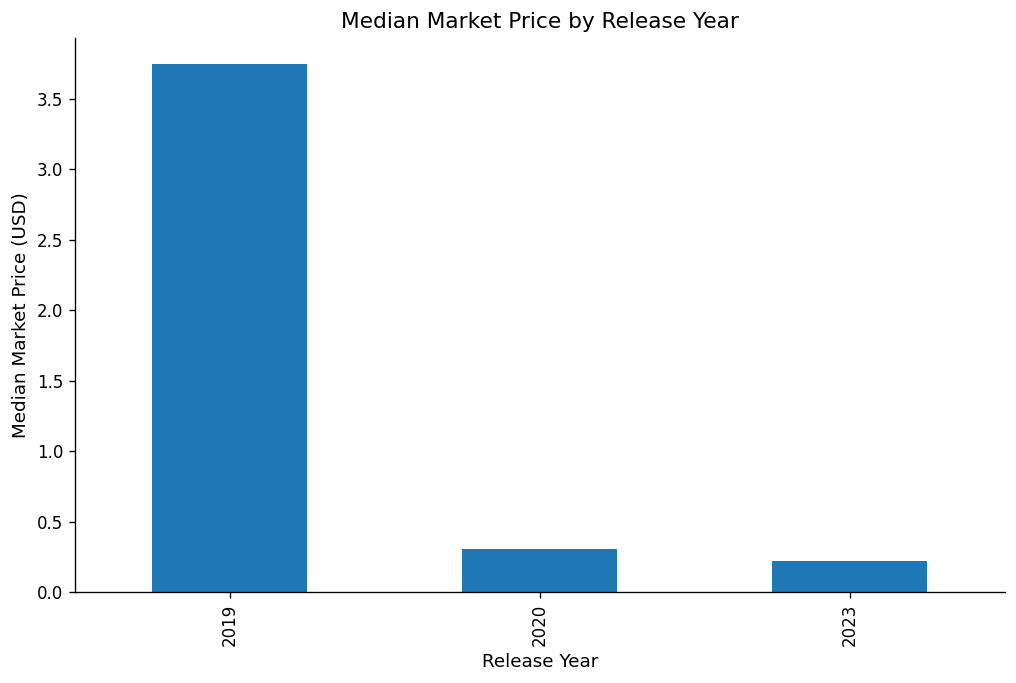

In [ ]:
# Extract release year

df['release_year'] = df['release_date'].dt.year

plt.figure(figsize=(10,6))

df.groupby('release_year')['market_price_usd'].median().plot(
    kind='bar'
)

plt.xlabel("Release Year")
plt.ylabel("Median Market Price (USD)")
plt.title("Median Market Price by Release Year")

plt.show()

##### Observation

The median market price varies considerably between different release years.

Cards released in 2019 have the highest median market price in the dataset, while cards from 2020 and 2023 show much lower typical values.

From the client's perspective, this suggests that release period may influence card value because older collections can have different levels of demand, availability, and collector interest.

From a data science perspective, release year may contain useful information for predicting market price. However, the dataset only contains a limited number of release years, so this relationship should be interpreted carefully because differences between years may also be caused by other factors such as rarity, set popularity, or the types of cards released during each period.

## EDA Findings Summary and Modelling Direction

The exploratory analysis shows that Pokémon card market price is influenced by multiple card characteristics rather than a single feature.

Rarity appears to be one of the strongest potential predictors because higher rarity categories generally represent fewer available cards and show differences in market value.

Other categorical features, including set, subtype, and Pokémon type, show differences in median prices and may provide additional information when combined with stronger predictors.

The analysis also shows that HP has a very weak relationship with market price, meaning gameplay statistics alone may not explain card value.

Release year may provide some useful information because different release periods show different median prices, although this relationship should be interpreted carefully because other factors such as rarity and set popularity may influence the difference.

Based on these findings, a supervised regression model is appropriate for the next phase because the goal is to predict a continuous outcome: market price in USD.

## Assumptions Log

During the exploratory analysis, several assumptions were made:

1. Market price is treated as the target variable because the goal is to estimate the monetary value of Pokémon cards.

2. Market price values are assumed to represent realistic market conditions. Extreme high-value cards are not removed because they may represent meaningful collector behaviour rather than errors.

3. Rarity categories are assumed to represent differences in card availability and collector demand.

4. Categorical variables such as rarity, Pokémon set, subtype, and type are assumed to contain useful information for predicting market value after encoding.

5. Release year is treated as a potential feature, but not as a direct indicator of value because age alone does not determine collector demand.

6. HP is included as a possible feature but is expected to have limited predictive value based on the correlation analysis.

## Initial Approach Decision

The project is treated as a supervised learning regression problem.

The objective is to predict Pokémon card market price in USD using known card attributes. Since market price is a continuous numerical value, regression models are more appropriate than classification models.

Potential input features include:

- Card rarity
- Pokémon set
- Pokémon type
- Subtype
- Release year
- HP
- Other available card characteristics

The planned workflow is:

1. Perform feature engineering on categorical variables.
2. Split the dataset into training and testing sets.
3. Train regression models.
4. Evaluate model performance using appropriate regression metrics such as RMSE and R².
5. Interpret which features contribute most to predicting card value.

The final model should provide a useful estimate of market price and help identify which card characteristics are most associated with higher collector value.

# Checkpoint 1 Progress Report

## Project Overview

This project focuses on predicting Pokémon card market prices using card characteristics from a structured dataset. The goal is to understand which features contribute to collector value and develop a model capable of estimating market price.

## Completed Work

The initial exploratory data analysis has been completed. The dataset was inspected for structure, missing values, duplicates, and data quality issues.

Several exploratory visualizations were created to understand relationships between card characteristics and market price, including:

- Market price distribution
- Log-transformed price distribution
- Price differences across rarity categories
- Median prices across Pokémon sets
- Median prices across Pokémon types
- Price trends by release year
- Correlation analysis between numerical features

## Main Findings

The analysis found that market price is highly uneven, with most cards having lower values and a small number of expensive cards creating a long right tail.

Rarity appears to be an important factor affecting card value, while numerical gameplay features such as HP show little relationship with price.

Different Pokémon sets and types also show differences in median prices, suggesting that multiple features should be considered together when building the prediction model.

## Next Steps

The next stage of the project will focus on:

- Feature engineering and encoding categorical variables
- Training regression models
- Comparing model performance
- Evaluating predictions using regression metrics
- Interpreting important features affecting Pokémon card prices
